In [1]:
import asyncio
import time

# 1. Define an Asynchronous Coroutine using 'async def'
async def fetch_amazon_api_data(api_name, delay_seconds):
    print(f"[API START] Requesting data from Amazon {api_name} Engine...")
    
    # We use asyncio.sleep() to simulate a network delay.
    # The 'await' keyword pauses this specific function and hands control back to the Event Loop.
    await asyncio.sleep(delay_seconds)
    
    print(f"[API COMPLETE] Successfully retrieved data from {api_name} Engine.")
    return {api_name: "Production_Data_Payload"}


# 2. Define the Master Coroutine to orchestrate the tasks
async def main():
    start_time = time.perf_counter()
    print("Initializing Asynchronous Inventory Dashboard Pipeline...")
    print("-" * 60)

    # We wrap our coroutines into explicit Task objects. 
    # This tells the Event Loop to prepare them for immediate execution.
    task_1 = asyncio.create_task(fetch_amazon_api_data("Pricing_API", 1.0))
    task_2 = asyncio.create_task(fetch_amazon_api_data("Review_API", 1.0))
    task_3 = asyncio.create_task(fetch_amazon_api_data("Logistics_API", 1.0))

    # asyncio.gather() blocks the main thread here until ALL tasks wrapped inside are resolved.
    # However, inside that window, the tasks run completely concurrently!
    combined_results = await asyncio.gather(task_1, task_2, task_3)
    
    print("-" * 60)
    print(f"All dashboards loaded successfully. Data Aggregated: {combined_results}")
    
    end_time = time.perf_counter()
    print(f"Total Asynchronous Execution Time: {end_time - start_time:.4f} seconds")

# =========================================================================
# RUNTIME ENGINE TRIGGER
# =========================================================================
if __name__ == "__main__":
    # To start an async application from scratch, we use asyncio.run().
    # This boots up the background Event Loop, inserts our main() coroutine, 
    # and shuts down the loop safely once everything concludes.
    asyncio.run(main())

RuntimeError: asyncio.run() cannot be called from a running event loop

In [2]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ==========================================
# STEP 1: GENERATE ENTERPRISE-SCALE DIRTY DATA
# ==========================================
print("=== Step 1: Generating Mock Real-World Dirty Dataset ===")

raw_data = {
    "Employee_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    "Age": [28.0, 34.0, np.nan, 45.0, 52.0, np.nan, 23.0, 39.0, 41.0, 30.0],
    "Annual_Salary": [
        55000.0,
        82000.0,
        61000.0,
        np.nan,
        140000.0,
        95000.0,
        np.nan,
        112000.0,
        88000.0,
        71000.0,
    ],
    "Department": [
        "Engineering",
        "HR",
        "Engineering",
        "Marketing",
        "Executive",
        "Engineering",
        "HR",
        np.nan,
        "Marketing",
        "Engineering",
    ],
    "Remote_Status": [
        "Remote",
        "Hybrid",
        "Onsite",
        "Remote",
        "Onsite",
        "Remote",
        np.nan,
        "Hybrid",
        "Remote",
        "Onsite",
    ],
    "Performance_Rating": [
        "High",
        "Medium",
        "Low",
        "Medium",
        "High",
        "High",
        "Low",
        "Medium",
        "Medium",
        "High",
    ],  # Target Variable
}

df = pd.DataFrame(raw_data)
print("\n--- Raw Input Dataframe ---")
print(df)
print("\n--- Missing Value Count Per Column ---")
print(df.isnull().sum())

# ==========================================
# STEP 2: DATA ARCHITECTURE SEPARATION
# ==========================================
print("\n=== Step 2: Slicing Features and Targets ===")

# Drop unique identifier keys that carry zero statistical weight
X = df.drop(columns=["Employee_ID", "Performance_Rating"])
y = df["Performance_Rating"]

# Programmatically segment feature types to build specialized pathways
numerical_features = ["Age", "Annual_Salary"]
categorical_features = ["Department", "Remote_Status"]

print(f"Numerical Features Pipeline Scope: {numerical_features}")
print(f"Categorical Features Pipeline Scope: {categorical_features}")

# Split data into Training and Test partitions using Stratified logic
# This prevents data leakage during the transformations
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ==========================================
# STEP 3: CONSTRUCT ENCAPSULATED PIPELINES
# ==========================================
print("\n=== Step 3: Configuring Preprocessing Transformers ===")

# Numerical Processing Sub-Engine: Handle missing entries then Standardize ranges
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),  # Robust against potential salary outliers
        ("scaler", StandardScaler()),  # Centers distribution around mean=0, std=1
    ]
)

# Categorical Processing Sub-Engine: Impute missing flags then cross-encode vectors
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),  # Fills missing values with Mode
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),  # Prevents crash on unseen validation categories
    ]
)

# Consolidate processing engines into a singular, comprehensive master executor
preprocessor = ColumnTransformer(
    transformers=[
        ("num_transform", numerical_pipeline, numerical_features),
        ("cat_transform", categorical_pipeline, categorical_features),
    ]
)

# ==========================================
# STEP 4: EXECUTE TRANSFORMATIONS EXCLUSIVELY
# ==========================================
print("\n=== Step 4: Executing Pipeline Pipeline Execution ===")

# Fit parameters ONLY on training set data to eliminate pipeline leakage
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation/test dataset using the historical calculations derived above
X_test_processed = preprocessor.transform(X_test)

# ==========================================
# STEP 5: OUTPUT EXTRACTION & ANALYSIS
# ==========================================
print("\n=== Step 5: Post-Execution Inspection ===")

# Extract structural columns created dynamically via One-Hot encoding array configurations
encoded_categorical_columns = (
    preprocessor.named_transformers_["cat_transform"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

all_engineered_features = numerical_features + encoded_categorical_columns

# Construct readable, production analytics DataFrames
X_train_processed_df = pd.DataFrame(
    X_train_processed, columns=all_engineered_features
)
X_test_processed_df = pd.DataFrame(
    X_test_processed, columns=all_engineered_features
)

print(
    f"\nProcessed Shape (Rows, Scaled Columns): {X_train_processed_df.shape}"
)
print("\n--- Final Cleaned & Transformed Training Array Framework ---")
print(X_train_processed_df.round(4))

=== Step 1: Generating Mock Real-World Dirty Dataset ===

--- Raw Input Dataframe ---
   Employee_ID   Age  Annual_Salary   Department Remote_Status  \
0          101  28.0        55000.0  Engineering        Remote   
1          102  34.0        82000.0           HR        Hybrid   
2          103   NaN        61000.0  Engineering        Onsite   
3          104  45.0            NaN    Marketing        Remote   
4          105  52.0       140000.0    Executive        Onsite   
5          106   NaN        95000.0  Engineering        Remote   
6          107  23.0            NaN           HR           NaN   
7          108  39.0       112000.0          NaN        Hybrid   
8          109  41.0        88000.0    Marketing        Remote   
9          110  30.0        71000.0  Engineering        Onsite   

  Performance_Rating  
0               High  
1             Medium  
2                Low  
3             Medium  
4               High  
5               High  
6                Low  
7  

In [5]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# STEP 1: CREATE REPLICABLE SAMPLE DATA
# ==========================================
print("=== Step 1: Synthesizing Real Estate Data ===")

# Generating pseudo-random data representing House Size vs House Price
np.random.seed(42)
house_sizes = np.random.randint(800, 3500, size=100)  # Features (Sq Ft)

# Target Price calculation containing realistic random variance (noise)
house_prices = (house_sizes * 150) + 50000 + np.random.normal(0, 15000, size=100)

df = pd.DataFrame({"Square_Footage": house_sizes, "Price": house_prices})
print(df.head(5))

# ==========================================
# STEP 2: DATA STRUCTURE DIVISION
# ==========================================
print("\n=== Step 2: Formulating Train and Test Matrix Boundaries ===")

# Scikit-learn expects feature inputs (X) to be a 2D matrix/DataFrame
X = df[["Square_Footage"]]
y = df["Price"]

# Divide into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# STEP 3: FEATURE SCALING
# ==========================================
print("\n=== Step 3: Standardizing Spatial Dimensions ===")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# STEP 4: INITIALIZE AND TRAIN THE MODEL
# ==========================================
print("\n=== Step 4: Instantiating and Fitting Linear Regression ===")

# Initialize the mathematical linear engine
model = LinearRegression()

# The machine iteratively adjusts weights to draw the optimal line
model.fit(X_train_scaled, y_train)

print("Status: Training Complete.")

# ==========================================
# STEP 5: PREDICTION & PRODUCTION METRICS
# ==========================================
print("\n=== Step 5: Inference Execution and Performance Assessment ===")

# Predict target values on unseen testing data
y_pred = model.predict(X_test_scaled)

# Calculate validation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error brings error back to original currency scale
r2 = r2_score(
    y_test, y_pred
)  # Tells us what percentage of variance the model explains

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared Score (Accuracy Variance Metric): {r2:.4f}")

# ==========================================
# STEP 6: EXTRACTING THE FOUND MATHEMATHICAL RULES
# ==========================================
print("\n=== Step 6: Inspecting Learned Model Parameters ===")

print(f"Learned Slope (Weight / Coefficient): {model.coef_[0]:.2f}")
print(f"Learned Intercept (Bias): {model.intercept_ :.2f}")

# Simulating an actual inference request
raw_new_house = np.array([[2200]])  # A house with 2200 Sq Ft
scaled_new_house = scaler.transform(raw_new_house)
predicted_valuation = model.predict(scaled_new_house)

print(
    f"\n[Production Run] Predicted value for a 2,200 sq ft house: ${predicted_valuation[0]:.2f}"
)

=== Step 1: Synthesizing Real Estate Data ===
   Square_Footage          Price
0            1660  295892.511648
1            2094  354747.839075
2            1930  316877.700657
3            1895  350744.704637
4            2438  413034.018181

=== Step 2: Formulating Train and Test Matrix Boundaries ===

=== Step 3: Standardizing Spatial Dimensions ===

=== Step 4: Instantiating and Fitting Linear Regression ===
Status: Training Complete.

=== Step 5: Inference Execution and Performance Assessment ===
Mean Squared Error (MSE): 150851173.04
Root Mean Squared Error (RMSE): $12282.15
R-squared Score (Accuracy Variance Metric): 0.9900

=== Step 6: Inspecting Learned Model Parameters ===
Learned Slope (Weight / Coefficient): 113619.89
Learned Intercept (Bias): 380827.91

[Production Run] Predicted value for a 2,200 sq ft house: $381197.55


/Users/amritansh/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Matplotlib is building the font cache; this may take a moment.


=== Step 1: Simulating Unlabeled E-Commerce Data on Disk ===
Success: Unstructured database written to: '/Users/amritansh/Adv_Python/Day_1/customer_behavior_data.csv'

=== Step 2: Ingesting Raw Data Matrix ===

--- First 5 Rows of Unlabeled Features Matrix ---
   Total_App_Visits_Per_Month  Total_Expenditure_USD
0                           7                1185.88
1                          20                1358.35
2                          29                  43.01
3                          15                1029.07
4                          11                 460.73

=== Step 3: Running Optimization Loop to Find Best 'K' ===


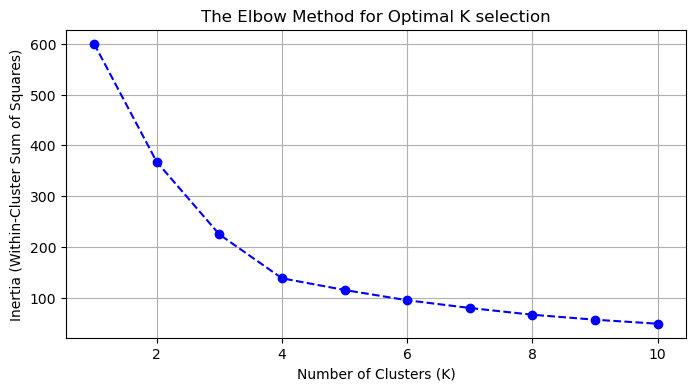


Look at the generated line graph: The point where the sharp drop flattens out (the elbow) is K=3.

=== Step 4: Training Final K-Means Framework with K=3 ===
Status: Clustering completed. Structural tags appended.

=== Step 5: Analyzing Characteristics of Discovered Segments ===

--- Discovered Customer Cluster Personas (Averages) ---
                       Total_App_Visits_Per_Month  Total_Expenditure_USD
Discovered_Cluster_ID                                                   
0                                            9.71                 382.17
1                                            8.59                1501.55
2                                           24.19                1078.31

--- Sample Distribution Count ---
Discovered_Cluster_ID
2    119
1     96
0     85


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ==========================================
# STEP 1: GENERATE UNSTRUCTURED CSV DATA
# ==========================================
print("=== Step 1: Simulating Unlabeled E-Commerce Data on Disk ===")

csv_filename = "customer_behavior_data.csv"

# Synthesize mock customer spending data (No labels/targets provided)
np.random.seed(42)
mock_users = 300

csv_data = {
    "Customer_ID": [f"CUST_{i}" for i in range(1, mock_users + 1)],
    "Total_App_Visits_Per_Month": np.random.randint(1, 30, size=mock_users),
    "Total_Expenditure_USD": np.random.uniform(10.0, 2000.0, size=mock_users).round(2)
}

# Save natively to the local Colab workspace directory
pd.DataFrame(csv_data).to_csv(csv_filename, index=False)
print(f"Success: Unstructured database written to: '{os.getcwd()}/{csv_filename}'")


# ==========================================
# STEP 2: INGEST CSV & EXTRACT FEATURES
# ==========================================
print("\n=== Step 2: Ingesting Raw Data Matrix ===")

df = pd.read_csv(csv_filename)

# Drop ID strings; we only isolate purely numerical attributes for geometry math
X = df.drop(columns=["Customer_ID"])

print("\n--- First 5 Rows of Unlabeled Features Matrix ---")
print(X.head())


# ==========================================
# STEP 3: THE ELBOW METHOD (OPTIMIZATION)
# ==========================================
print("\n=== Step 3: Running Optimization Loop to Find Best 'K' ===")

inertia_scores = []
k_range = range(1, 11)

# Because K-Means requires scaled inputs, we scale inside the loop 
# to keep the distances geometrically sound for every test run
for k in k_range:
    temp_pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10))
    ])
    temp_pipeline.fit(X)
    # Extract inertia from the final named step of our pipeline
    inertia_scores.append(temp_pipeline.named_steps["kmeans"].inertia_)

# Generate the Elbow Plot natively in Colab output window
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia_scores, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K selection')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

print("\nLook at the generated line graph: The point where the sharp drop flattens out (the elbow) is K=3.")


# ==========================================
# STEP 4: EXECUTE PRODUCTION K-MEANS 
# ==========================================
print("\n=== Step 4: Training Final K-Means Framework with K=3 ===")

optimal_k = 3

final_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10))
])

# Run distance vectors through iterations until convergence
final_pipeline.fit(X)

# Extract cluster assignments
cluster_labels = final_pipeline.predict(X)

# Append the discovered rules back to our original DataFrame for analysis
df["Discovered_Cluster_ID"] = cluster_labels

print("Status: Clustering completed. Structural tags appended.")


# ==========================================
# STEP 5: ENTERPRISE PROFILE ANALYSIS
# ==========================================
print("\n=== Step 5: Analyzing Characteristics of Discovered Segments ===")

# Calculate the mean behavior traits of each cluster to build business profiles
cluster_profiles = df.drop(columns=["Customer_ID"]).groupby("Discovered_Cluster_ID").mean()

print("\n--- Discovered Customer Cluster Personas (Averages) ---")
print(cluster_profiles.round(2))

print("\n--- Sample Distribution Count ---")
print(df["Discovered_Cluster_ID"].value_counts().to_string())

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ==========================================
# STEP 1: GENERATE STATIC CSV DATA ON DISK
# ==========================================
print("=== Step 1: Simulating Raw Real Estate CSV Ingestion ===")

csv_filename = "raw_housing_market_data.csv"

# Synthesize a mock dataset of 10 houses
np.random.seed(42)
csv_data = {
    "Square_Footage": [1200, 1500, 850, 2100, 3100, 1800, 1350, 2700, 950, 2200],
    "Bedrooms": [2, 3, 1, 3, 4, 3, 2, 4, 1, 3],
    "Sale_Price_USD": [180000, 225000, 130000, 310000, 465000, 270000, 202000, 405000, 145000, 330000]
}

# Save natively to the local Colab directory
pd.DataFrame(csv_data).to_csv(csv_filename, index=False)
print(f"Success: File successfully created at: '{os.getcwd()}/{csv_filename}'")


# ==========================================
# STEP 2: READ CSV AND SEGMENT FEATURES (X) & TARGET (y)
# ==========================================
print("\n=== Step 2: Loading CSV and Separating Array Dimensions ===")

df = pd.read_csv(csv_filename)

# Feature Matrix (X) - Input variables the model uses to learn
X = df[["Square_Footage", "Bedrooms"]]

# Target Vector (y) - The continuous number we want to predict
y = df["Sale_Price_USD"]

print(f"Total Rows in Ingested Dataset: {len(df)}")


# ==========================================
# STEP 3: THE GOLDEN SPLIT IMPLEMENTATION
# ==========================================
print("\n=== Step 3: Executing train_test_split (80% Train / 20% Test) ===")

# train_test_split returns 4 separate arrays in an exact sequential order:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,      # Allocates exactly 20% of the rows to the test partition
    random_state=42      # Seed number to ensure the random shuffle is identical every time you run it
)

print("Status: Data successfully segmented.")


# ==========================================
# STEP 4: VERIFICATION AND DATA INSPECTION
# ==========================================
print("\n=== Step 4: Verification Metrics ===")

print(f"Training Features Shape (X_train): {X_train.shape} -> (Rows, Features)")
print(f"Testing Features Shape (X_test)  : {X_test.shape}  -> (Rows, Features)")

print("\n--- The 80% Training Set (Used for Learning) ---")
# Combining X and y visually for display purposes
train_verification = X_train.copy()
train_verification["Sale_Price_USD"] = y_train
print(train_verification)

print("\n--- The 20% Testing Set (Kept in Complete Isolation) ---")
test_verification = X_test.copy()
test_verification["Sale_Price_USD"] = y_test
print(test_verification)